<a href="https://colab.research.google.com/github/yeji79/BioBigData/blob/main/bio_bigdata_workshop_1A_python_pandas_visualization_practice_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 바이오 빅데이터 분석 (1A): Python/Pandas Bridge + Visualization Practice

### 이 노트북의 목적
이 노트북은 파이썬 기초 문법을 한 번 배운 수강생이 실제 바이오 빅데이터 분석 코드로 넘어가기 위한 실습 자료입니다.  
문법 자체를 길게 반복하기보다는, 생명과학/의학 데이터 분석에서 자주 쓰는 `pandas DataFrame`과 기본 시각화 흐름을 실제 데이터로 연습합니다.

### 실습 주제
1. 바이오 데이터 테이블 구조 이해와 pandas DataFrame 핵심 복습
2. TCGA-BRCA 유방암 데이터의 gene expression과 clinical metadata 다루기
3. DataFrame 선택, 조건 필터링, `groupby`, table 결합 연습
4. 데이터 분포 시각화: histogram, pairplot, boxplot, violin plot, heatmap

### 사용할 데이터
1. CancerSEEK data: 단백질 marker와 임상 정보
2. TCGA-BRCA cohort: 유방암 gene expression과 clinical subtype
3. CCLE-CTRPv2: 암세포주 gene expression과 약물 반응 AUC

#### Machine Learning and Bioinformatics (MLBI) Lab


## 0. 필요한 패키지 설치 (처음 한번만 하면 됨)

In [ ]:
# 수업 환경에서 mlbi-lab 또는 scikit-network가 없을 때만 주석을 해제하고 실행하세요. (클러스터링, 통계검정 할 때 쓸 패키지)
!pip install mlbi-lab scikit-network statannotations

In [ ]:
!pip list

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind, mannwhitneyu, f_oneway, kruskal

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import cluster, mixture
from sklearn.neighbors import kneighbors_graph

from sknetwork.clustering import Louvain
from mlbi.datasets import load_data

In [ ]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


## 1. Data Frame의 구조와 활용법 실습

### 분석 관점에서 보는 DataFrame

생명과학/의학 데이터 분석에서는 대부분의 자료가 표 형태로 정리됩니다.

- 행(row): 샘플, 환자, 세포주, 실험 조건
- 열(column): 유전자, 단백질, 임상 변수, 약물 반응값
- index: 각 행을 구분하는 이름 또는 ID
- values: 실제 측정값

엑셀과 비슷해 보이지만, `pandas DataFrame`은 행/열 선택, 조건 필터링, 통계 요약, 시각화 연동을 코드로 재현할 수 있다는 점이 중요합니다.

In [ ]:
# 아주 작은 예제 DataFrame을 먼저 만들어 봅니다.
# 실제 바이오 데이터도 구조는 이 예제와 같습니다.

example_df = pd.DataFrame({
    'sample_id': ['S1', 'S2', 'S3', 'S4'],
    'subtype': ['Lum.A', 'Lum.B', 'Basal', 'Her2'],
    'ESR1': [12.4, 8.1, 1.2, 4.5],
    'ERBB2': [3.1, 4.0, 2.8, 14.2],
    'MKI67': [2.3, 7.8, 9.1, 6.5]
})

example_df

,sample_id,subtype,ESR1,ERBB2,MKI67
0,S1,Lum.A,12.4,3.1,2.3
1,S2,Lum.B,8.1,4.0,7.8
2,S3,Basal,1.2,2.8,9.1
3,S4,Her2,4.5,14.2,6.5


In [ ]:
example_df.max(axis=0)
example_df[['ESR1', 'ERBB2']].std()

,0
ESR1,4.811445
ERBB2,5.473801


### 빠른 복습: 한 열과 여러 열 선택

`df['ESR1']`은 한 열을 `Series`로 가져오고, `df[['ESR1', 'ERBB2']]`는 여러 열을 `DataFrame`으로 가져옵니다.  
대괄호가 하나인지 두 개인지에 따라 결과의 타입이 달라진다는 점을 자주 확인하세요.

In [ ]:
california_housing_df

In [ ]:
example_df.to_csv('example_df.csv')

In [ ]:
print(type(example_df['ESR1']))
print(type(example_df[['ESR1', 'ERBB2']]))

example_df[['ESR1', 'ERBB2']]

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,ESR1,ERBB2
0,12.4,3.1
1,8.1,4.0
2,1.2,2.8
3,4.5,14.2


### 빠른 복습: 조건으로 샘플 고르기

아래 예시는 `ESR1` 발현량이 높은 샘플만 고르는 코드입니다.  
실제 분석에서는 특정 subtype, 특정 stage, 특정 발현량 기준에 맞는 샘플을 고를 때 같은 방식을 씁니다.

In [ ]:
high_esr1 = example_df[example_df['ESR1'] > 5]
high_esr1

### 데이터 불러오기 - CancerSEEK data

In [ ]:
load_data()

You can select one of:
  cancerseek
  ccle-ctrpv2
  heart_failure
  hotel_bookings
  house_price
  labor_force
  metabric
  scores
  tcga-brca
  time-series
  time-series2


In [ ]:
data = load_data('cancerseek')
data.keys()

dict_keys(['protein_expression', 'clinical_info'])

In [ ]:
df_pep = data['protein_expression']
df_clinical = data['clinical_info']
#환자의 39개 단백질 elisa 측정치 바이오 마커 값들
df_pep.head()

,AFP,Angiopoietin-2,AXL,CA-125,CA 15-3,CA19-9,CD44,CEA,CYFRA 21-1,DKK1,...,Prolactin,sEGFR,sFas,SHBG,sHER2/sEGFR2/sErbB2,sPECAM-1,TGFa,Thrombospondin-2,TIMP-1,TIMP-2
Sample ID #,,,,,,,,,,,,,,,,,,,,,
CRC 455 PLS 1,1583.450,5598.50,3621.04,5.090,19.08,16.452,9.81,540.0,1938.654,0.78,...,11606.60,3284.17,204.792,55.06,6832.07,9368.53,16.086,21863.74,56428.71,39498.82
CRC 456 PLS 1,715.308,20936.35,2772.96,7.270,10.04,40.910,27.57,5902.0,1938.654,0.77,...,14374.99,1911.81,204.792,72.92,5549.47,6224.55,16.086,29669.66,73940.49,41277.09
CRC 457 PLS 1,4365.530,2350.93,4120.77,4.854,16.96,16.452,14.59,974.0,1976.940,0.90,...,38375.00,1743.94,204.792,173.78,3698.16,4046.48,179.030,6020.47,22797.28,28440.60
CRC 458 PLS 1,715.308,1604.34,2029.96,5.390,8.31,16.452,7.78,2028.0,1938.654,0.64,...,12072.51,1059.24,204.792,29.47,5856.00,6121.93,16.086,4331.02,20441.19,25896.73
CRC 459 PLS 1,801.300,2087.57,2069.17,4.854,11.73,16.452,12.21,615.0,1938.654,0.78,...,23718.17,1736.92,204.792,78.07,5447.93,6982.32,16.086,2311.91,56288.51,49425.20


In [ ]:
#데이터규격확인
df_pep.shape, df_clinical.shape

((1803, 39), (1803, 11))

In [ ]:
df_clinical['AJCC Stage'].value_counts()
#print(df_clinical['AJCC Stage'].isnull().sum()) # .sum()을 추가하여 결측값의 개수를 출력합니다.

799


In [ ]:
df_clinical['Tumor type'].value_counts()

,count
Tumor type,
Normal,799
Colorectum,388
Breast,208
Lung,104
Pancreas,93
Stomach,68
Ovary,54
Esophagus,45
Liver,44


In [ ]:
df_clinical['Tumor type'].hist()

### Understanding `np.log10` with `hist()`

As explained, `CA19-9` is in `df_pep`. A common approach is to apply a logarithmic transformation to highly skewed data, like many protein expression values, to better visualize their distribution. Let's plot the histogram of the `CA19-9` values after applying a `log10` transformation.

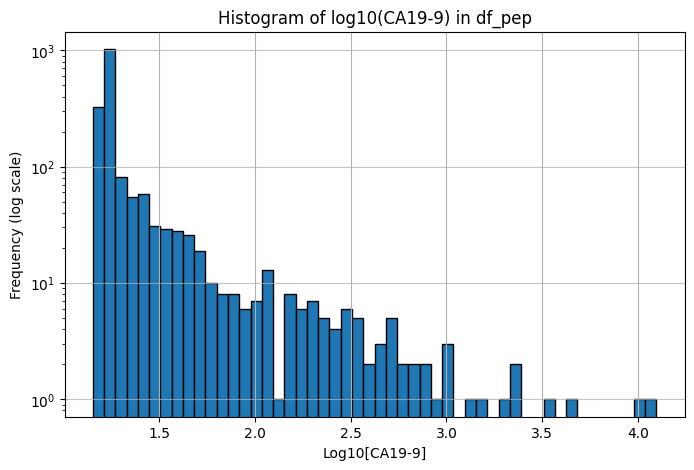

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Check if 'CA19-9' column exists in df_pep and plot its log10 histogram
if 'CA19-9' in df_pep.columns:
    plt.figure(figsize=(8, 5))
    np.log10(df_pep['CA19-9']).hist(bins=50, edgecolor='black', log=True) # Added log=True
    plt.title('Histogram of log10(CA19-9) in df_pep')
    plt.xlabel('Log10[CA19-9]') # Updated xlabel as requested
    plt.ylabel('Frequency (log scale)') # Updated ylabel to reflect log scale
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("Error: 'CA19-9' column not found in df_pep.")

Text(0.5, 0, 'Log10[CA19-9]')

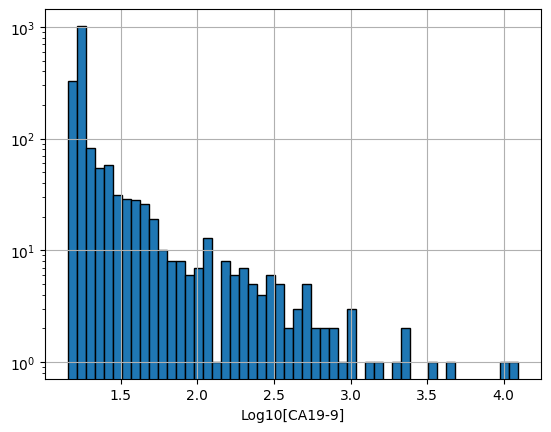

In [ ]:
np.log10(df_pep['CA19-9']).hist(bins=50, edgecolor='black', log=True)
plt.xlabel('Log10[CA19-9]')

### 다른 데이터셋 - TCGA BRCA gene expression and clinical data

* 이미 오래된 데이터이기 때문에 다른 데이터셋 분석 후에 보조자료로 사용하면 좋음

In [ ]:
data = load_data('tcga-brca')
data.keys()

Loading TCGA-BRCA data .. done


dict_keys(['gene_expression', 'clinical_info'])

In [ ]:
df_gep = data['gene_expression']
df_clinical = data['clinical_info']

In [ ]:
df_gep.shape, df_clinical.shape
#1932개 샘플, mRNA 20531 유전자에 대한 발현량만 들어가 있음
#랜덤 샘플링이어서 노이즈가 있고 추정치라ㅡㄴ 사실을 기억해야함
#에티더가 100프로 정확하다고 생각하면 안됨 10%는 거짓말을 하고 있다고 생각해야함

((1092, 20531), (1092, 32))

In [ ]:
df_clinical.columns.values

array(['pid', 'age', 'gender', 'hist.type', 'menopause.status',
       'surgical.proc', 'init.metastasis', 'patho.stage', 'M.Stage',
       'N.Stage', 'T.Stage', 'Patho.Stage', 'er.status', 'pr.status',
       'her2.status', 'PAM50.class', 'subtype', 'radiation.therapy',
       'chemo.therapy', 'hormone.therapy', 'immuno.therapy',
       'ancillary.therapy', 'target.mole.therapy', 'other.therapy',
       'therapy', 'vital.status', 'days.to.event', 'cancer.status',
       'days.to.date.of.last.contact', 'days.to.date.of.death',
       'OS.event', 'OS.Time'], dtype=object)

In [ ]:
np.1og10([])

In [ ]:
df_clinical['init.metastasis'].value_counts()

,count
init.metastasis,
no,381
yes,12


In [ ]:
df_clinical.isnull().sum()

,0
pid,0
age,7
gender,7
hist.type,8
menopause.status,96
surgical.proc,63
init.metastasis,699
patho.stage,15
M.Stage,7
N.Stage,7


In [ ]:
df_clinical.head()

,pid,age,gender,hist.type,menopause.status,surgical.proc,init.metastasis,patho.stage,M.Stage,N.Stage,...,target.mole.therapy,other.therapy,therapy,vital.status,days.to.event,cancer.status,days.to.date.of.last.contact,days.to.date.of.death,OS.event,OS.Time
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.AR.A251.01A.12R.A169.07,TCGA.AR.A251,51.0,female,infiltrating ductal carcinoma,pre,other,NaN,stage iiia,M0,N2,...,0,0,BOTH,alive,3030.0,tumor free,1373.0,NaN,0.0,3030.0
TCGA.BH.A1FR.01A.11R.A13Q.07,TCGA.BH.A1FR,73.0,female,"other, specify",NaN,other,NaN,stage iiib,M0,N1,...,0,0,NO,dead,1642.0,with tumor,1642.0,1642.0,1.0,1642.0
TCGA.BH.A8G0.01A.11R.A352.07,TCGA.BH.A8G0,54.0,female,infiltrating lobular carcinoma,peri,simple mastectomy,NaN,stage iib,M0,N1,...,0,0,CO,alive,662.0,tumor free,662.0,NaN,0.0,662.0
TCGA.A8.A096.01A.11R.A00Z.07,TCGA.A8.A096,73.0,female,infiltrating ductal carcinoma,post,other,NaN,stage iia,M0,N0,...,0,0,NO,alive,0.0,tumor free,0.0,NaN,0.0,0.0
TCGA.A8.A09E.01A.11R.A00Z.07,TCGA.A8.A09E,73.0,female,infiltrating ductal carcinoma,post,other,NaN,stage iiib,M0,N1,...,0,0,HO,alive,943.0,with tumor,942.0,NaN,0.0,943.0


In [ ]:
df_clinical.columns.values

array(['pid', 'age', 'gender', 'hist.type', 'menopause.status',
       'surgical.proc', 'init.metastasis', 'patho.stage', 'M.Stage',
       'N.Stage', 'T.Stage', 'Patho.Stage', 'er.status', 'pr.status',
       'her2.status', 'PAM50.class', 'subtype', 'radiation.therapy',
       'chemo.therapy', 'hormone.therapy', 'immuno.therapy',
       'ancillary.therapy', 'target.mole.therapy', 'other.therapy',
       'therapy', 'vital.status', 'days.to.event', 'cancer.status',
       'days.to.date.of.last.contact', 'days.to.date.of.death',
       'OS.event', 'OS.Time'], dtype=object)

In [ ]:
df_gep.shape, df_clinical.shape

In [ ]:
df_gep

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.AR.A251.01A.12R.A169.07,0.0,5.2,0.9,2.9,94.9,0.0,7.1,0.1,0.0,0.0,...,2.3,24.8,77.4,17.9,81.1,153.3,140.6,99.2,23.6,0.0
TCGA.BH.A1FR.01A.11R.A13Q.07,0.0,0.4,0.1,2.8,42.0,0.0,12.9,0.0,0.0,0.0,...,4.9,53.2,66.4,3.5,58.0,128.0,87.3,95.3,12.3,0.0
TCGA.BH.A8G0.01A.11R.A352.07,0.0,0.4,0.9,3.8,32.5,0.0,22.3,0.0,0.0,0.0,...,3.4,22.8,54.0,6.2,37.2,258.8,100.6,49.3,24.5,0.0
TCGA.A8.A096.01A.11R.A00Z.07,0.0,0.1,0.2,4.8,36.3,0.0,2.8,0.0,0.0,0.0,...,4.0,23.9,56.2,0.2,41.7,167.7,80.4,60.4,1.3,0.0
TCGA.A8.A09E.01A.11R.A00Z.07,0.0,0.2,0.4,4.2,37.0,0.0,21.8,0.0,0.0,0.0,...,3.9,27.9,70.6,1.8,38.1,121.8,70.9,22.3,1.2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.BH.A0B0.01A.21R.A115.07,0.0,0.2,0.2,5.5,62.3,0.0,4.9,0.0,0.0,0.0,...,3.9,22.2,47.4,3.1,31.2,193.5,48.8,41.2,3.6,0.0
TCGA.UU.A93S.01A.21R.A41B.07,0.0,0.2,0.5,6.7,141.7,0.0,9.0,0.0,0.0,0.0,...,1.0,9.9,44.6,0.6,27.5,274.7,26.4,19.0,0.4,0.0
TCGA.BH.AB28.01A.31R.A41B.07,0.0,0.6,0.9,5.4,32.5,0.0,17.6,0.1,0.0,0.0,...,4.8,43.2,68.8,1.6,47.3,226.5,123.1,37.8,3.9,0.0


In [ ]:
df_gep.sum(axis = 1)

,0
TCGA.barcode,
TCGA.AR.A251.01A.12R.A169.07,999975.8
TCGA.BH.A1FR.01A.11R.A13Q.07,999951.2
TCGA.BH.A8G0.01A.11R.A352.07,999973.1
TCGA.A8.A096.01A.11R.A00Z.07,999975.8
TCGA.A8.A09E.01A.11R.A00Z.07,999984.9
...,...
TCGA.BH.A0B0.01A.21R.A115.07,999990.5
TCGA.UU.A93S.01A.21R.A41B.07,999974.4
TCGA.BH.AB28.01A.31R.A41B.07,999976.7


In [ ]:
b = df_gep['ESR1'] >= 10
#true인 애들만 (10보다 크거나 같은 애들만)
df_gep.loc[b].shape

(904, 20531)

In [ ]:
#sorting, esr1을 오름차순으로 sorting - ascending=True
df_gep.sort_values(by='ESR1')

,100130426,100133144,100134869,10357,10431,136542,155060,26823,280660,317712,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR
TCGA.barcode,,,,,,,,,,,,,,,,,,,,,
TCGA.E2.A158.01A.11R.A12D.07,0.0,2.9,2.2,3.6,56.7,0.0,24.9,0.1,0.0,0.0,...,3.2,31.8,90.2,19.0,44.3,384.1,40.6,94.3,53.4,0.0
TCGA.AQ.A54N.01A.11R.A266.07,0.0,0.0,0.3,7.4,141.3,0.0,28.1,0.0,0.0,0.0,...,1.0,10.2,72.1,10.1,26.0,407.2,55.5,30.3,17.3,0.0
TCGA.A2.A3XV.01A.21R.A239.07,0.0,0.0,0.2,3.5,94.2,0.0,11.8,0.0,0.0,0.0,...,0.3,7.8,23.2,11.1,16.3,246.8,16.0,15.3,0.6,0.0
TCGA.A2.A0D0.01A.11R.A00Z.07,0.0,0.1,0.1,11.5,65.6,0.0,5.8,0.0,0.0,0.0,...,0.9,11.9,81.0,15.2,48.6,411.5,25.1,46.6,0.2,0.0
TCGA.A2.A04U.01A.11R.A115.07,0.0,0.0,0.0,20.5,218.4,0.0,3.9,0.0,0.0,0.0,...,0.9,8.7,43.6,6.5,29.3,160.4,30.7,62.9,4.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.E9.A1R7.01A.11R.A14M.07,0.0,0.6,0.3,5.6,62.4,0.0,7.3,0.1,0.0,0.0,...,4.5,45.6,69.2,33.2,110.0,48.1,51.1,61.9,0.5,0.0
TCGA.AQ.A1H2.01A.11R.A13Q.07,0.0,0.4,0.2,1.9,54.5,0.0,5.2,0.1,0.0,0.0,...,4.3,37.3,57.3,3.7,61.2,73.1,65.9,42.2,0.4,0.0
TCGA.D8.A1XC.01A.11R.A14D.07,0.0,0.2,0.3,2.7,28.6,0.0,5.8,0.1,0.0,0.0,...,6.2,51.5,75.6,1.5,51.2,102.5,111.1,106.9,0.4,0.0


### DataFrame 활용 연습
1. head() method를 이용한 Data frame 확인: head(), tail()
2. shape attribute를 이용한 size 확인: shape
3. row name(index) 및 column name 확인
4. index/column name을 이용한 행/열 가져오기: loc(), iloc()
5. pandas series
6. NA(None)이 포함된 element 확인하기: isnull()
7. 행/열의 합/평균/표준편차 구하기: sum(), mean(), std()
8. 행/열의 최대값/최소값/최대값의 index 구하기: max(), min(), idxmax(), idxmin()
9. 범주형 데이터의 범주 카운트 구하기: value_counts()
10. 조건에 맞는 행들만 선택하기 - boolean indexing
11. 범주형 데이터가 특정 집합의 원소인지 아닌지 조사하기: isin()
12. 등호/부등호의 사용: ==, >, <
13. 특정 열 기준으로 정렬하기: sort_values()

In [ ]:
# TCGA-BRCA gene expression table과 clinical table을 이용해 DataFrame 기본기를 연습합니다.

print('gene expression shape:', df_gep.shape)
print('clinical info shape:', df_clinical.shape)

# 1) 앞/뒤 일부 행 확인
print('--- df_gep head ---')
display(df_gep.head())

print('--- df_clinical head ---')
display(df_clinical.head())

### DataFrame 핵심 조작 예제

아래 셀들은 실제 분석에서 거의 매번 쓰는 조작입니다.  
처음에는 코드를 외우기보다, “행을 고르는지, 열을 고르는지, 조건을 거는지”를 구분해서 읽는 것이 중요합니다.

In [ ]:
# 열 이름 확인
print(df_gep.columns[:10])
print(df_clinical.columns)

# 관심 유전자 3개만 선택
marker_genes = ['ESR1', 'ERBB2', 'MKI67']
df_marker = df_gep[marker_genes]

df_marker.head()

In [ ]:
# loc: index/column 이름으로 선택
# iloc: 행/열 번호 위치로 선택

print('첫 번째 샘플 ID:', df_gep.index[0])

display(df_gep.loc[df_gep.index[0], marker_genes])
display(df_gep.iloc[:5, :5])

In [ ]:
# 임상 정보에서 subtype별 샘플 수 확인
# value_counts()는 범주형 변수의 분포를 볼 때 자주 사용합니다.

df_clinical['subtype'].value_counts(dropna=False)

In [ ]:
# gene expression과 clinical subtype을 하나의 DataFrame으로 합치기
# 두 table의 index가 같은 sample ID라고 가정하고 열 방향(axis=1)으로 붙입니다.

practice_df = pd.concat([
    df_gep[marker_genes],
    df_clinical[['subtype']]
], axis=1)

practice_df.head()

In [ ]:
# 조건 필터링: Basal-like 샘플만 선택
basal_df = practice_df[practice_df['subtype'] == 'Basal']

print(basal_df.shape)
basal_df.head()

In [ ]:
# groupby: subtype별 marker gene 평균과 표준편차 계산
summary_mean = practice_df.groupby('subtype')[marker_genes].mean()
summary_std = practice_df.groupby('subtype')[marker_genes].std()

print('Subtype별 평균')
display(summary_mean)

print('Subtype별 표준편차')
display(summary_std)

### 다른 데이터셋 - CCLE cellline gene expression and drug response measurement

In [ ]:
data = load_data('ccle-ctrpv2')
data.keys()

In [ ]:
df_gexp = data['gene_expression']
df_cl_info = data['cellline_info']
df_auc = data['auc']
df_ec50 = data['ec50']
df_drug_info = data['drug_info']

### Homework

유방암은 크게 3가지의 subtype (Basal-like, Luminal 및 Her2)으로 구분한다. 또한, Lum.subtype은 다시 liminal A와 Luminal B로 나뉜다. 이들 subtype들은 대체로 3가지 유전자(ESR1, ERBB2, MKI67)의 발현량에 따라 구분되기도 한다. 3가지의 subtype (Basal-like, Luminal 및 Her2) 각각에 대해 3가지 유전자 (ESR1, ERBB2, MKI67)의 발현량의 평균과 표준편자를 각각 구하여 data frame으로 요약해 보아라. 이 때 data frame의 index는 subtype의 이름, columns는 유전자 이름으로 설정하라. (예, 'ESR1 (mean)', 'ESR1 (stdev)' 등) 이를 위해 필요한 정보는 TCGA-BRCA 데이터에 모두 포함되어 있으며 해당 데이터를 잘 살펴보고 필요 시 다음의 인터넷 사이트를 참고하라. NA가 포함된 부분은 적절히 제외하라.
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html    

#### Homework 접근 힌트

1. `df_gep[['ESR1', 'ERBB2', 'MKI67']]`로 관심 유전자만 고릅니다.
2. `df_clinical[['subtype']]`을 함께 붙여 분석용 DataFrame을 만듭니다.
3. `dropna()`로 subtype 또는 발현량 결측치를 정리합니다.
4. `groupby('subtype')` 뒤에 `mean()`과 `std()`를 적용합니다.
5. 결과를 보기 좋은 하나의 DataFrame으로 정리합니다.

In [ ]:
# Homework template
# 아래 빈칸을 채워 subtype별 ESR1/ERBB2/MKI67 평균과 표준편차를 계산해 보세요.

marker_genes = ['ESR1', 'ERBB2', 'MKI67']

hw_df = pd.concat([
    df_gep[marker_genes],
    df_clinical[['subtype']]
], axis=1)

hw_df = hw_df.dropna(subset=marker_genes + ['subtype'])

# subtype_summary = ...
# subtype_summary

## 2. 데이터 분포의 시각화 연습

시각화는 “분석 결과를 예쁘게 보여주는 단계”라기보다, 데이터가 어떤 모양인지 먼저 확인하는 탐색 과정입니다.  
특히 바이오 데이터에서는 극단값, subtype별 차이, marker gene 간 관계를 눈으로 확인하는 과정이 중요합니다.

1. Histogram: 한 변수의 전체 분포
2. Pairplot: 여러 변수 간 관계
3. Box plot: 그룹별 분포 비교
4. Violin plot: 그룹별 분포 모양 비교
5. Heatmap / clustermap: 여러 유전자 패턴 비교

In [ ]:
data = load_data('tcga-brca')

df_gep = data['gene_expression']
df_clinical = data['clinical_info']

Loading TCGA-BRCA data .. done


In [ ]:
#원래 지수분포에 가깝기 때문에 좀 더 정규분포에 가깝게 만들기 위해서 log 변환을 시켜주는 것
#df_gep['ESR1'].hist(bins=50)
df_log_gep = np.log10(df_gep + 1)

In [ ]:
df_log_gep['ESR1'].hist(bins=50)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7fec2a380040> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7fec2a311580> (for post_execute):


KeyboardInterrupt: 

In [ ]:
#esr1의 분포를 보고 발현량보다 작으면 negative


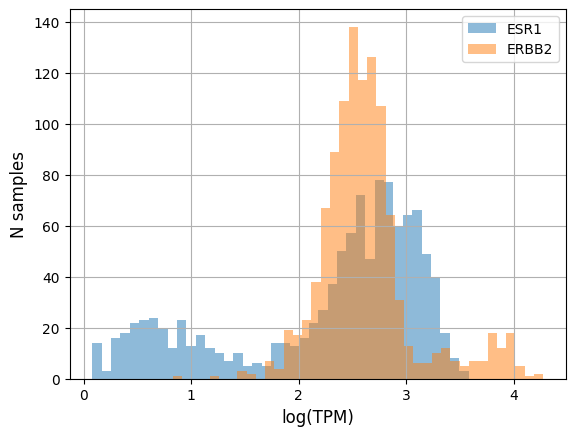

In [ ]:
df_log_gep['ESR1'].hist(bins = 40, alpha = 0.5)
df_log_gep['ERBB2'].hist(bins = 40, alpha = 0.5)

plt.xlabel('log(TPM)', fontsize = 12)
plt.ylabel('N samples', fontsize = 12)
plt.legend(['ESR1', 'ERBB2'])
plt.title('Gene expression of ESR1 and ERBB2')

#### pair wise scatter plot 그리기
* 특징이 너무 많으면 좀 그래서 몇개를 골라서 그림

In [ ]:

df = df_log_gep[['ESR1', 'ERBB2', 'MKI67']].copy(deep = True)
df['subtype'] = df_clinical['subtype'].copy(deep=True) #유방암 subtupe(범주형)을 붙이기
df

,ESR1,ERBB2,MKI67,subtype
TCGA.barcode,,,,
TCGA.AR.A251.01A.12R.A169.07,1.320146,2.166430,2.651375,Basal
TCGA.BH.A1FR.01A.11R.A13Q.07,3.412712,2.401228,1.666518,Lum.A
TCGA.BH.A8G0.01A.11R.A352.07,2.466868,2.672098,1.127105,Lum.A
TCGA.A8.A096.01A.11R.A00Z.07,2.899821,2.492621,2.168792,Lum.A
TCGA.A8.A09E.01A.11R.A00Z.07,3.065356,2.880070,1.899273,Lum.B
...,...,...,...,...
TCGA.BH.A0B0.01A.21R.A115.07,2.474508,2.284431,1.685742,Lum.A
TCGA.UU.A93S.01A.21R.A41B.07,0.707570,4.271707,1.973128,Her2
TCGA.BH.AB28.01A.31R.A41B.07,2.963079,2.997648,1.830589,Lum.A


In [ ]:
df['subtype'].value_counts()

,count
subtype,
Lum.A,622
Basal,196
Lum.B,187
Her2,87


In [ ]:
df.head()

,ESR1,ERBB2,MKI67,subtype
TCGA.barcode,,,,
TCGA.AR.A251.01A.12R.A169.07,1.320146,2.166430,2.651375,Basal
TCGA.BH.A1FR.01A.11R.A13Q.07,3.412712,2.401228,1.666518,Lum.A
TCGA.BH.A8G0.01A.11R.A352.07,2.466868,2.672098,1.127105,Lum.A
TCGA.A8.A096.01A.11R.A00Z.07,2.899821,2.492621,2.168792,Lum.A
TCGA.A8.A09E.01A.11R.A00Z.07,3.065356,2.880070,1.899273,Lum.B


In [ ]:
df['subtype'].value_counts()

,count
subtype,
Lum.A,622
Basal,196
Lum.B,187
Her2,87


#### Pairplot 해석 포인트

각 점은 한 환자 샘플이고, 색은 유방암 subtype입니다.  
`ESR1`, `ERBB2`, `MKI67` 세 유전자만으로도 일부 subtype이 서로 다른 위치에 모이는지 관찰해 봅니다.

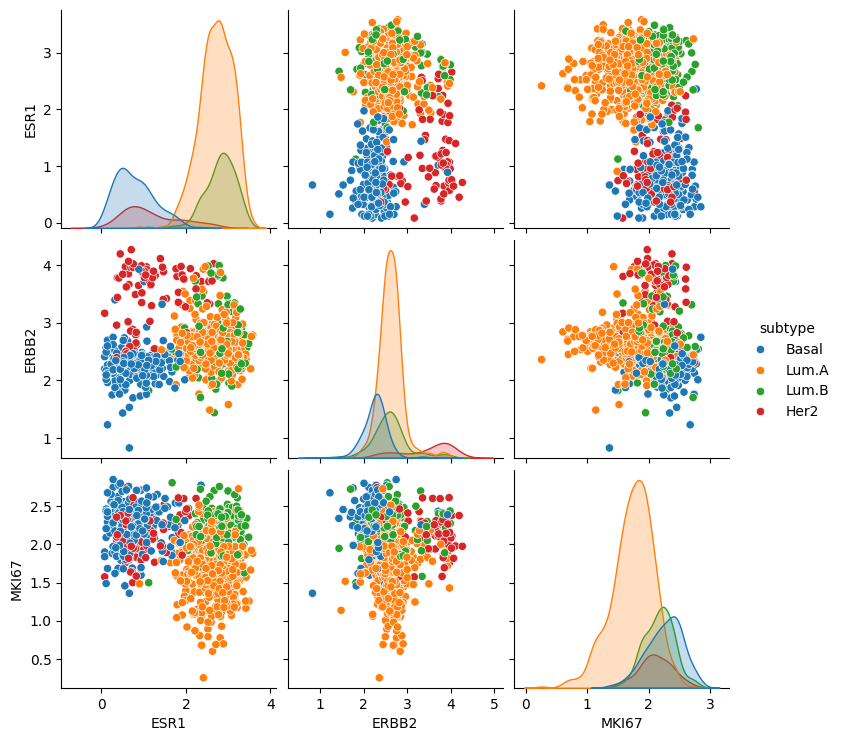

In [ ]:
## Pairplot with hue
sns.pairplot(df, hue = 'subtype', diag_kind = 'kde')

#### Box plot 그리기
* 그룹간의 분포의 차이를 조금 더 정량화 해서 보는것
* 가운데서 median 값
* Q1
* 하위 25%
* 상위 75%
* 이 범위를 벗어난 값들 outlier - 점으로 찍어서 나타냄

<Axes: >

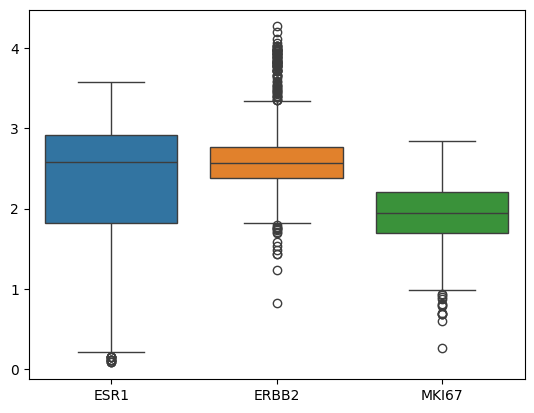

In [ ]:
sns.boxplot(data = df.iloc[:,:3])

<Axes: xlabel='subtype', ylabel='ERBB2'>

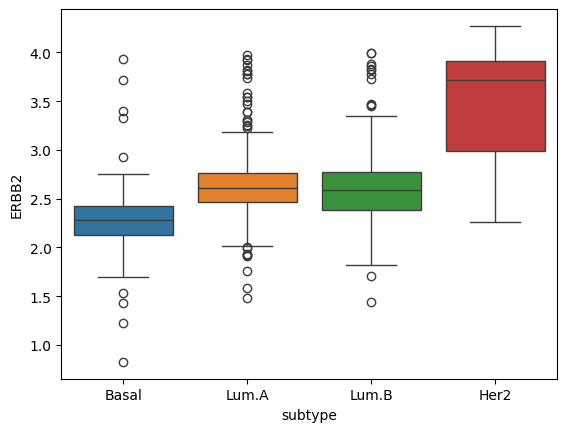

In [ ]:
#ERbBB2만 선택, 각각의 유방암 subtype의 ERBB2 분포를 확인
#분포가 서로 비슷하면 의미가 았는데 그렇지 않으면 ㄴㄴ
sns.boxplot(data = df, y = 'ERBB2', x = 'subtype', hue = 'subtype')

#### Violin plot 그리기

<Axes: xlabel='subtype', ylabel='ERBB2'>

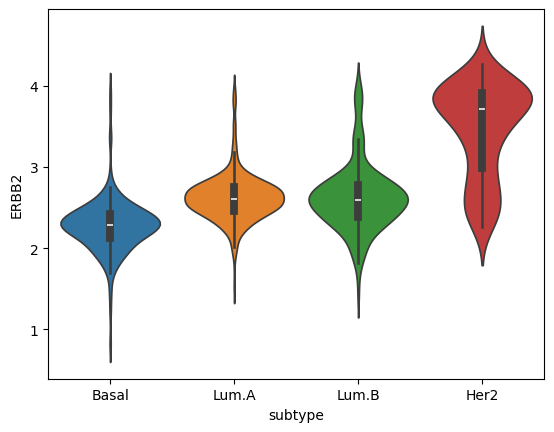

In [ ]:
sns.violinplot(data = df, y = 'ERBB2', x = 'subtype', hue = 'subtype') #기본 설정 bw=1 -> 이걸 0.2로 줄이면 덜 스무스하게 나와서 자글자글함이 좀 더 보임
#HER2는 정규분포의 형태를 따르지 않는 것을 확인하고 두 그룹으로 또 나눌 수 있겠다는 것을 생각해볼 수 있다.
#다른 subtype들은 정규분포를 따른다.

#### Heatmap 그리기
* matrix를 한 눈에 볼 수 있도록 그리는 방법

#### Clustering
* 유사도를 따져서 계층적으로 클러스터 하는 것

In [ ]:
#유전자를 다 보기엔 너무 많아서 50개만 뽑음
PAM50_genes = ['ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA',
 'CCNB1', 'CCNE1', 'CDC20', 'CDC6', 'CDH3', 'CENPF', 'CEP55',
 'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 'FOXA1',
 'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'KRT14', 'KRT17', 'KRT5',
 'MAPT', 'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11', 'MYBL2',
 'MYC', 'NAT1', 'NDC80', 'NUF2', 'ORC6L', 'PGR', 'PHGDH', 'PTTG1',
 'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T']

PAM50_genes = list(set(PAM50_genes).intersection(df_log_gep.columns.values))
len(PAM50_genes)

50

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(1163.6527777777778, 0.5, 'Gene')

<Figure size 960x400 with 0 Axes>

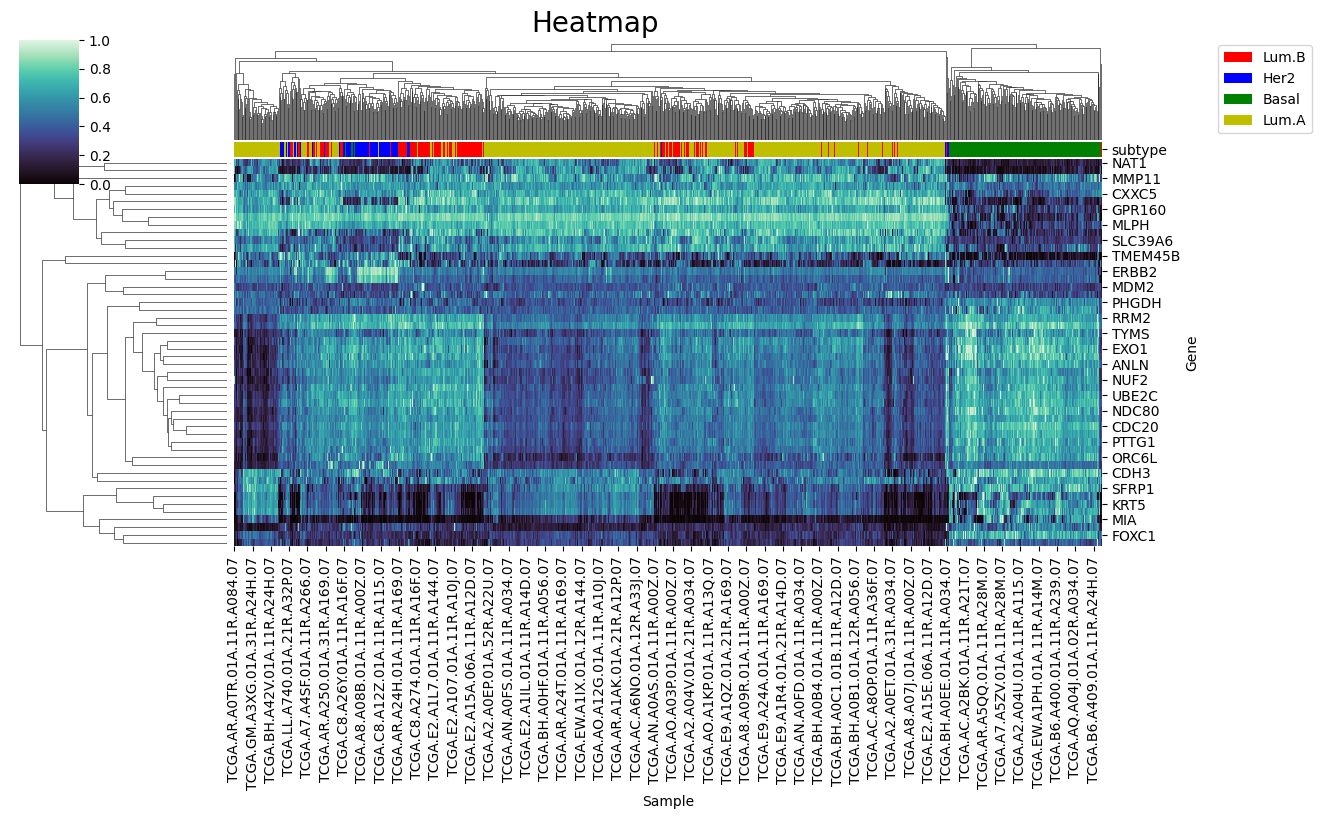

In [ ]:
#x유전자, 발현량
#맨 위 색깔 바는 암의 subtype
#subtype 별로 유전자에 따라 발현 패턴을 보는 것
#rna-seq gene expression 볼 때 자주 사용
#통계검정 박스플롯 많이 사용

X_sel = df_log_gep[PAM50_genes] # .copy(deep=True)
# X_sel = df_log_gep[['ESR1', 'ERBB2', 'MKI67']]
y = df_clinical['subtype']

plt.figure(num=None, figsize=(12, 5), dpi=80, facecolor='w', edgecolor='k')
# ax = sb.heatmap(X_sel.transpose())

lut = dict(zip(set(y), "rbgym"))
col_colors = y.map(lut)
dfc = pd.DataFrame([col_colors]).transpose()

g = sns.clustermap(X_sel.transpose(), col_cluster = True, row_cluster = True, standard_scale = 0,
                   col_colors = dfc, cmap="mako", figsize = (12,8))
g.fig.suptitle('Heatmap\n ', fontsize=20, va = 'center')

# Draw the legend bar for the classes
for label in list(set(y)):
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc="center right", bbox_to_anchor=(1.25, 0.5), ncol=1)
# ax.cax.set_position([.2, .2, .03, 1])
g.ax_heatmap.set_xlabel('Sample')
g.ax_heatmap.set_ylabel('Gene')

### Homework

유방암은 크게 3가지의 subtype (Basal-like, Luminal 및 HER2-enriched)으로 구분한다. 또한, Luminal subtype은 다시 liminal A와 Luminal B로 나뉜다. 이들 subtype들은 대체로 3가지 유전자(ESR1, ERBB2, MKI67)의 발현량에 따라 구분되기도 한다.

1. 3가지의 subtype (Basal-like, Luminal 및 HER2-enriched) 각각에 대해 3가지 유전자 (ESR1, ERBB2, MKI67)의 발현량를 Violin plot으로 그려서 비교해 보아라. NA가 포함된 부분은 적절히 제외하라.
2. 3가지의 subtype (Basal-like, Luminal 및 HER2-enriched) 각각에 대해 3가지 유전자 (ESR1, ERBB2, MKI67)의 발현량를 Cluster Map으로 그려서 비교해 보아라.
3. 1/2의 비교 굘과에 대한 간략한 고찰을 제시하여라.